## Inferencia Causal y Uplift Modeling: Optimización de Campañas de Marketing Directo

### 1. Introducción, Contexto de Negocio y Carga de datos

Se tiene como objetivo analizar el impacto causal de una campaña de email marketing usando el dataset de Hillstrom (MineThatData). A diferencia de enfoques tradicionales que miden métricas superficiales (visitas), optimizaremos el impacto sobre la conversión y el gasto (spend).
Además de medir el Average Treatment Effect (ATE) se avanzará hacia la personalización de políticas (CATE), identificando a los usuarios que pueden ser "Persuadibles" para maximizar el ROI de la campaña y evitar el desgaste de los clientes.

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import KFold
import xgboost as xgb
from sklift.metrics import qini_curve, uplift_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
url = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
df = pd.read_csv(url)


In [2]:
df

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63995,10,2) $100 - $200,105.54,1,0,Urban,0,Web,Mens E-Mail,0,0,0.0
63996,5,1) $0 - $100,38.91,0,1,Urban,1,Phone,Mens E-Mail,0,0,0.0
63997,6,1) $0 - $100,29.99,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0
63998,1,5) $500 - $750,552.94,1,0,Surburban,1,Multichannel,Womens E-Mail,0,0,0.0


In [ ]:
# Se unifican 'Mens E-Mail' y 'Womens E-Mail' en un solo grupo de Tratamiento (1), y 'No E-Mail' será Control (0) para simplificar inferencia.
df['treatment'] = np.where(df['segment'] == 'No E-Mail', 0, 1)

print(f"Total de observaciones: {len(df)}")
print(df['treatment'].value_counts(normalize=True))

Total de observaciones: 64000
treatment
1    0.667094
0    0.332906
Name: proportion, dtype: float64


**Nota metodológica:** para simplificar la estimación del ATE y el CATE, unificamos los brazos `Mens E-Mail` y `Womens E-Mail` en una sola variable `treatment`. Esto significa que este análisis responde a *"¿vale la pena contactar a este cliente con un email, sin importar cuál?"*, no a *"¿qué campaña (hombre/mujer) es mejor para este cliente?"*. Se documenta como una decisión consciente dado el alcance ilustrativo del proyecto; un siguiente paso natural sería extender el T-learner a un esquema más robusto multi-brazo (3 modelos: `No E-Mail` / `Mens` / `Womens`) y obtener resultados más completos.

### 2. Check de Balance de Covariables 

En cualquier experimento aleatorizado (RCT), es un error asumir ciegamente que la asignación fue perfecta. Antes de medir el impacto, debemos verificar que las características pre-tratamiento (covariables) estén balanceadas entre el grupo Control y Tratamiento. Si no lo están, el efecto causal estaría sesgado. Realizaremos pruebas de hipótesis (T-test para variables continuas y Chi-cuadrada para categóricas).

In [ ]:
# Variables a balancear (Covariables)
categorical_vars = ['recency', 'history_segment', 'zip_code', 'mens', 'womens', 'newbie', 'channel']
continuous_vars = ['history']

balance_results = []

# Test Chi-Square para variables categóricas
for var in categorical_vars:
    contingency_table = pd.crosstab(df['treatment'], df[var])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    balance_results.append({'Variable': var, 'Test': 'Chi-Square', 'P-Value': p_val})

# Test T-Test para variables continuas
for var in continuous_vars:
    group_t = df[df['treatment'] == 1][var]
    group_c = df[df['treatment'] == 0][var]
    t_stat, p_val = stats.ttest_ind(group_t, group_c, equal_var=False)
    balance_results.append({'Variable': var, 'Test': 'T-Test (Welch)', 'P-Value': p_val})

balance_df = pd.DataFrame(balance_results)
balance_df['Balanced (alpha=0.05)'] = balance_df['P-Value'] > 0.05
display(balance_df)

,Variable,Test,P-Value,Balanced (alpha=0.05)
0,recency,Chi-Square,0.845542,True
1,history_segment,Chi-Square,0.504711,True
2,zip_code,Chi-Square,0.533406,True
3,mens,Chi-Square,0.435632,True
4,womens,Chi-Square,0.460166,True
5,newbie,Chi-Square,0.927305,True
6,channel,Chi-Square,0.840115,True
7,history,T-Test (Welch),0.398157,True


### 3. ATE y el Problema de las Comparaciones Múltiples

Queremos medir el impacto del email en tres métricas: Visitas, Conversión y Gasto (Spend). Un error común es probar múltiples hipótesis usando el mismo nivel de significancia $(\alpha = 0.05)$, lo que infla la probabilidad de cometer un Error Tipo I (falso positivo). Para ser rigurosos, aplicaremos la Corrección de Bonferroni: al medir 3 métricas, nuestro nuevo umbral de significancia será 
$\alpha = 0.05/3=0.0167$

In [ ]:
metrics = ['visit', 'conversion', 'spend']
alpha_original = 0.05

# Corrección de Bonferroni
alpha_bonferroni = alpha_original / len(metrics)
print(f"Nuevo umbral de significancia (Bonferroni): {alpha_bonferroni:.4f}\n")

ate_results = []

for metric in metrics:
    # Se separan grupos
    treat_data = df[df['treatment'] == 1][metric]
    ctrl_data = df[df['treatment'] == 0][metric]
    
    # Se calcula ATE 
    mean_t = treat_data.mean()
    mean_c = ctrl_data.mean()
    ate = mean_t - mean_c
    lift = (ate / mean_c) * 100 if mean_c != 0 else 0
    
    # Welch's T-Test para manejar varianzas distintas
    t_stat, p_val = stats.ttest_ind(treat_data, ctrl_data, equal_var=False)
    
    # Se valida significancia con Bonferroni
    is_significant = p_val < alpha_bonferroni
    
    ate_results.append({
        'Métrica': metric.capitalize(),
        'Media Control': round(mean_c, 5),
        'Media Tratamiento': round(mean_t, 5),
        'ATE (Impacto Absoluto)': round(ate, 5),
        'Lift Relativo (%)': round(lift, 2),
        'P-Value': p_val,
        f'Significativo (<{alpha_bonferroni:.4f})': is_significant
    })

ate_df = pd.DataFrame(ate_results)
display(ate_df)

Nuevo umbral de significancia (Bonferroni): 0.0167



,Métrica,Media Control,Media Tratamiento,ATE (Impacto Absoluto),Lift Relativo (%),P-Value,Significativo (<0.0167)
0,Visit,0.10617,0.16705,0.06088,57.35,5.093420e-106,True
1,Conversion,0.00573,0.01068,0.00495,86.53,5.044426e-12,True
2,Spend,0.65279,1.24959,0.59680,91.42,1.148372e-07,True


### Entonces... Todo esto ¿Qué significa?

- El impacto es real y se comprueba cuando a pesar de ser más estrictos con el umbral estadístico (aplicando Bonferroni), la campaña de email demostró tener un impacto causal positivo y altamente significativo tanto en el tráfico (Visitas), como en el comportamiento de compra (Conversión) y los ingresos (Spend).

- La conversión se incrementó en aproximadamente un 86.53% relativo frente al grupo control. El gasto promedio (Spend) aumentó en aproximadamente $0.60 dólares por usuario contactado.

- El problema del ATE radica en que sabemos que la campaña funciona en promedio, contactar a toda la base asume un costo por envío y un riesgo de fatiga de email. El ATE no nos dice a quién debemos enviarle el correo ¿qué sigue ahora? Es necesario estimar el Efecto Heterogéneo (CATE).

### 4. El Modelo CATE (T-Learner con Cross-Fitting)

In [ ]:
#NOTA: El CATE estimado aquí responde a "¿contactar o no?", no a "¿con qué campaña?" — ver nota de la sección 1.*

# One-Hot Encoding para categóricas, creación de variables dummies
features = ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
X = pd.get_dummies(df[features], drop_first=True)

# objetivo principal: CONVERSIÓN
y = df['conversion']
t = df['treatment']

# Validación cruzada con K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Array para  nuestro CATE (Uplift) para cada usuario
cate_estimates = np.zeros(len(df))

# 3. El Loop de Cross-Fitting
fold = 1
for train_index, val_index in kf.split(X):
    # Separar Train y Validation para este fold
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, t_train = y.iloc[train_index], t.iloc[train_index]
    
    # Se separa Tratamiento (1) y Control (0) en el conjunto de entrenamiento
    X_train_t1 = X_train[t_train == 1]
    y_train_t1 = y_train[t_train == 1]
    
    X_train_t0 = X_train[t_train == 0]
    y_train_t0 = y_train[t_train == 0]
    
    # Se inicializan modelos base (T-learner, XGBoost)
    # Usamos parámetros conservadores para evitar sobreajuste
    model_t1 = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model_t0 = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    
    model_t1.fit(X_train_t1, y_train_t1)
    model_t0.fit(X_train_t0, y_train_t0)
    
    # [:, 1] da la probabilidad de conversión (clase 1)
    pred_t1 = model_t1.predict_proba(X_val)[:, 1]
    pred_t0 = model_t0.predict_proba(X_val)[:, 1]
    
    # CATE = Probabilidad si recibe correo - Probabilidad si NO recibe correo
    cate_estimates[val_index] = pred_t1 - pred_t0
    print(f"Fold {fold} completado.")
    fold += 1

df['CATE_conversion'] = cate_estimates

print("\nEstadísticas del CATE estimado:")
print(df['CATE_conversion'].describe())

Fold 1 completado.
Fold 2 completado.
Fold 3 completado.
Fold 4 completado.
Fold 5 completado.

Estadísticas del CATE estimado:
count    64000.000000
mean         0.004928
std          0.007576
min         -0.108361
25%          0.001747
50%          0.004550
75%          0.008044
max          0.087038
Name: CATE_conversion, dtype: float64


La predicción del Uplift para cada cliente en nuestro dataset fue generada por un modelo que nunca vio a ese cliente durante su entrenamiento (predicciones out-of-fold). Esto **reduce** el riesgo de sobreajuste optimista frente a un split único, aunque no lo elimina por completo: cada modelo base (`model_t1`, `model_t0`) puede seguir generando ruido, y en este caso el grupo de tratamiento combinado (Mens + Womens) tiene el doble de observaciones que el grupo de control, lo que puede introducir una
asimetría en qué tan bien ajusta cada modelo. La evaluación de la sección 5 (curva Qini y uplift por decil) es justamente el chequeo para detectar si ese ruido es relevante en el estudio y, como se podrá observar más adelante, el ranking es confiable en los extremos pero no es perfectamente monótono en los deciles intermedios.

### 5. Evaluación Causal (Curva Qini / Uplift Curve)

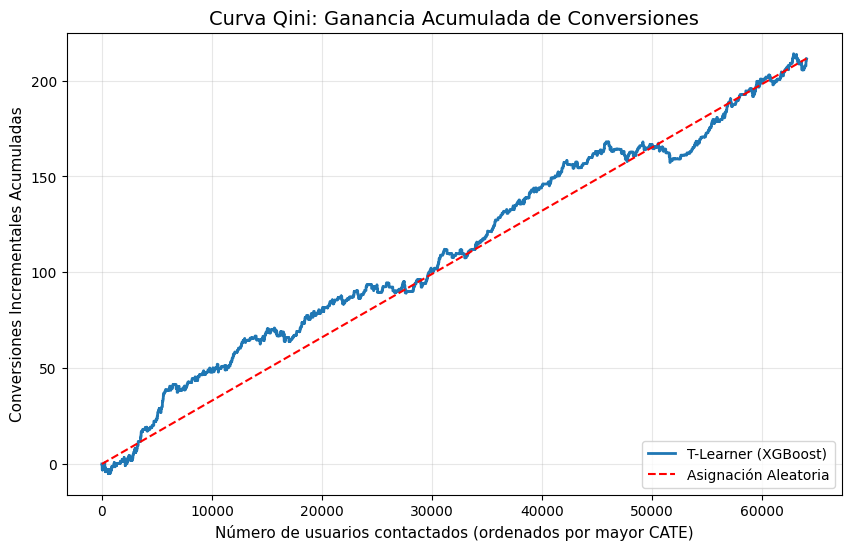

In [ ]:
# Extraer los puntos para la curva Qini
x_qini, y_qini = qini_curve(y_true=df['conversion'], 
                            uplift=df['CATE_conversion'], 
                            treatment=df['treatment'])

plt.figure(figsize=(10, 6))

plt.plot(x_qini, y_qini, label='T-Learner (XGBoost)', color='#1f77b4', linewidth=2)

# Graficar la línea base (asignación aleatoria)
plt.plot([x_qini[0], x_qini[-1]], [y_qini[0], y_qini[-1]], 
         label='Asignación Aleatoria', color='red', linestyle='--')

plt.title('Curva Qini: Ganancia Acumulada de Conversiones', fontsize=14)
plt.xlabel('Número de usuarios contactados (ordenados por mayor CATE)', fontsize=11)
plt.ylabel('Conversiones Incrementales Acumuladas', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

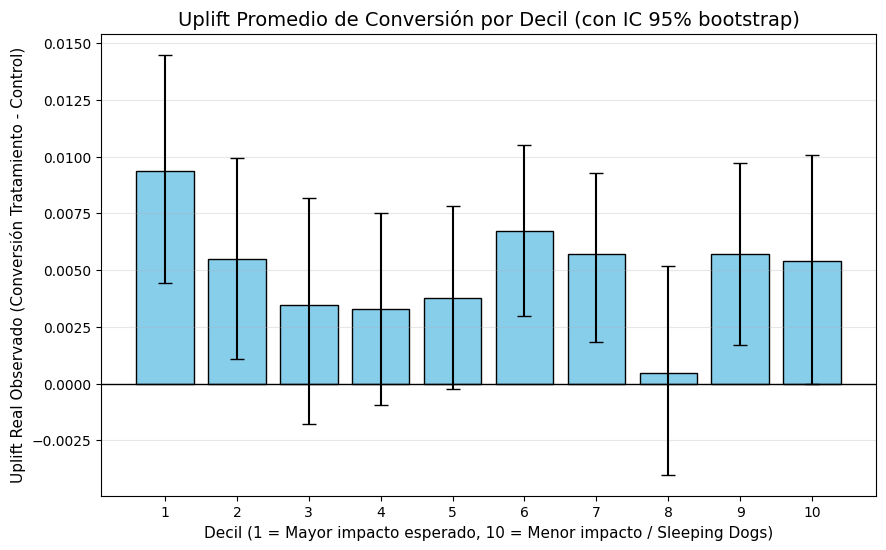

In [16]:
# Se ordena el dataset entero por nuestra predicción de Uplift (CATE) de mayor a menor
df_sorted = df.sort_values(by='CATE_conversion', ascending=False).copy()

# Se dividen a los usuarios en deciles
# Decil 1 = Los más persuadibles (mayor CATE), Decil 10 = Los menos persuadibles
df_sorted['decile'] = pd.qcut(np.arange(len(df_sorted)), 10, labels=np.arange(1, 11))

N_BOOT = 1000
rng = np.random.default_rng(42)

decile_uplift, decile_ci_low, decile_ci_high = [], [], []

for d in range(1, 11):
    subset = df_sorted[df_sorted['decile'] == d]
    t1 = subset.loc[subset['treatment'] == 1, 'conversion'].values
    t0 = subset.loc[subset['treatment'] == 0, 'conversion'].values

    point_uplift = (t1.mean() if len(t1) else 0) - (t0.mean() if len(t0) else 0)
    decile_uplift.append(point_uplift)

    # Bootstrap: remuestrea con reemplazo dentro de cada brazo del decil (1,000 iteraciones)
    boot_diffs = []
    for _ in range(N_BOOT):
        bt1 = rng.choice(t1, size=len(t1), replace=True) if len(t1) else np.array([0.0])
        bt0 = rng.choice(t0, size=len(t0), replace=True) if len(t0) else np.array([0.0])
        boot_diffs.append(bt1.mean() - bt0.mean())

    lo, hi = np.percentile(boot_diffs, [2.5, 97.5])
    decile_ci_low.append(lo)
    decile_ci_high.append(hi)

decile_uplift = np.array(decile_uplift)
decile_ci_low = np.array(decile_ci_low)
decile_ci_high = np.array(decile_ci_high)

# Gráfica con barras de error (IC 95% bootstrap)
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(1, 11)
err_low = decile_uplift - decile_ci_low
err_high = decile_ci_high - decile_uplift

ax.bar(x, decile_uplift, color='skyblue', edgecolor='black',
       yerr=[err_low, err_high], capsize=5, ecolor='black')

ax.set_title('Uplift Promedio de Conversión por Decil (con IC 95% bootstrap)', fontsize=14)
ax.set_xlabel('Decil (1 = Mayor impacto esperado, 10 = Menor impacto / Sleeping Dogs)', fontsize=11)
ax.set_ylabel('Uplift Real Observado (Conversión Tratamiento - Control)', fontsize=11)
ax.set_xticks(x)
ax.axhline(0, color='black', linewidth=1)
ax.grid(axis='y', alpha=0.3)
plt.show()

### 6. Conclusiones

**La campaña funciona de forma robusta.** Incluso tras aplicar la corrección de Bonferroni (el estándar más estricto en este caso), el email generó un incremento causal significativo en conversión (+86.53% relativo) y en gasto (+$0.60 por usuario contactado), por lo tanto, este es un efecto que estadísticamente se sostiene.

El modelo de targeting (CATE) sirve parcialmente para priorizar a quién contactar, y de forma medible gracias a los intervalos de confianza bootstrap:

- **El extremo superior es confiable.** El decil 1 (los clientes que el modelo identifica como más persuadibles) tiene el uplift más alto (~0.0093) y su intervalo de confianza al 95% no cruza el cero (~0.0045 a 0.0145). El modelo acierta en identificar a los mejores candidatos.
- **El ranking fino del rango medio no es confiable.** Varios deciles intermedios (3, 4, 5) tienen intervalos que se solapan entre sí, y el decil 8 que a simple vista parecería una anomalía ("sleeping dogs") tiene un intervalo de confianza que sí cruza cero (aproximadamente -0.004 a 0.005). Esto confirma estadísticamente que  ese salto no es una señal real de un segmento de clientes a quienes el email perjudica, es ruido muestral dentro de un decil con pocas observaciones. Sin el bootstrap, hubiéramos podido interpretar esto incorrectamente como un hallazgo de negocio ("existen sleeping dogs") cuando en realidad no hay evidencia suficiente para afirmarlo.

**Recomendación de negocio.** Este modelo debe usarse para decidir **a quién sí priorizar** (top decil/quintil, donde el efecto es grande y estadísticamente sólido), pero no para decidir **a quién excluir** basándose en los deciles bajos ya que gracias al ruido existente — no es posible sustentar una decisión de exclusión.

**Limitación reconocida y siguiente paso:** este análisis responde a "¿contactar o no?", no a "¿con qué campaña?", porque los brazos Mens/Womens se unificaron en un solo tratamiento. Dado que un análisis exploratorio previo sugiere que ambas campañas no tienen el mismo
efecto, el siguiente paso natural es extender este T-learner (incluso algo más robusto como un X-learner) a un esquema multi-brazo (3 modelos independientes: No E-Mail / Mens / Womens) para poder recomendar, además de a quién contactar, con qué tipo de publicidad.